# The Simpsons Image Classification using Convolutional Neural Networks in PyTorch
 

Importing Libraries

In [1]:
import os
import torch
import torchvision
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.transforms as tt
from torch.utils.data import random_split
from torchvision.utils import make_grid
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import torchvision.transforms as transforms
from torchvision.transforms import ToTensor
matplotlib.rcParams['figure.facecolor'] = '#ffffff'

In [ ]:
project_name= 'Final Project'

# Dataset used
This dataset contains image segmentations each for 5 Simpson's main characters (Homer, Lisa, Bert, Marge, and Maggie). I have taken these images from the Simpsons Characters Data on Kaggle.
The dataset contains two folders that is train_images for training and validation and test_images for testing the model.The model will be trained using convolutional neural network covered in the course by Jovian.ml named as Deep Learning with PyTorch: Zero to GANs.
 
 https://www.kaggle.com/mlwhiz/simpsons-main-characters

Importing Dataset

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
os.environ['KAGGLE_CONFIG_DIR'] = "/content/gdrive/My Drive/Kaggle"

In [ ]:
%cd /content/gdrive/My Drive/Kaggle

/content/gdrive/My Drive/Kaggle


In [ ]:
!kaggle datasets download -d mlwhiz/simpsons-main-characters

 95% 146M/153M [00:06<00:00, 17.7MB/s]
100% 153M/153M [00:07<00:00, 22.7MB/s]


In [ ]:
!ls

kaggle.json  simpsons-main-characters.zip


In [ ]:
#unzipping the zip files and deleting the zip files
!unzip \*.zip  && rm *.zip

Streaming output truncated to the last 5000 lines.
  inflating: SimpsonsInstanceSegmentation-coco/test_images/bart_simpson/pic_1037.jpg  
  inflating: SimpsonsInstanceSegmentation-coco/test_images/bart_simpson/pic_1038.jpg  
  inflating: SimpsonsInstanceSegmentation-coco/test_images/bart_simpson/pic_1039.jpg  
  inflating: SimpsonsInstanceSegmentation-coco/test_images/bart_simpson/pic_1040.jpg  
  inflating: SimpsonsInstanceSegmentation-coco/test_images/bart_simpson/pic_1041.jpg  
  inflating: SimpsonsInstanceSegmentation-coco/test_images/bart_simpson/pic_1042.jpg  
  inflating: SimpsonsInstanceSegmentation-coco/test_images/bart_simpson/pic_1043.jpg  
  inflating: SimpsonsInstanceSegmentation-coco/test_images/bart_simpson/pic_1044.jpg  
  inflating: SimpsonsInstanceSegmentation-coco/test_images/bart_simpson/pic_1045.jpg  
  inflating: SimpsonsInstanceSegmentation-coco/test_images/bart_simpson/pic_1046.jpg  
  inflating: SimpsonsInstanceSegmentation-coco/test_images/bart_simpson/pic_104

The dataset is extracted to the directory data/simpsonsInstanceSegmentation. It contains 2 folders train_images and test_images. Each of them contains 5 folders, one for each class of images. Let's verify this using os.datadir.

In [122]:
data_dir = '/content/gdrive/MyDrive/Kaggle/SimpsonsInstanceSegmentation-coco'
print(os.listdir(data_dir))
classes = os.listdir(data_dir + '/train_images')
print(classes)

['instances.json', 'train_images', 'test_images']
['bart_simpson', 'homer_simpson', 'lisa_simpson', 'maggie_simpson', 'marge_simpson']


In [40]:
classes2 = os.listdir(data_dir+ '/test_images')
print(classes2)

['bart_simpson', 'homer_simpson', 'lisa_simpson', 'maggie_simpson', 'marge_simpson']


In [41]:
bart_simpson_files = os.listdir(data_dir + "/train_images/bart_simpson")
print('No. of training examples for bart_simpson:', len(bart_simpson_files))
print(bart_simpson_files[:5])

No. of training examples for bart_simpson: 1261
['pic_0306.jpg', 'pic_0165.jpg', 'pic_0087.jpg', 'pic_0179.jpg', 'pic_0264.jpg']


In [123]:
dataset = ImageFolder(data_dir+'/train_images', transform=ToTensor())

In [124]:
len(dataset)

5956

# Checking the Image shape and Image Tensor
Let's look at a sample element from the training dataset. Each element is a tuple, containing a image tensor and a label.

In [125]:
im_count = 0
for image,_ in dataset:
  im_count += 1
  print(image.shape)
  if im_count == 10:
    break 

torch.Size([3, 464, 320])
torch.Size([3, 416, 288])
torch.Size([3, 379, 256])
torch.Size([3, 480, 640])
torch.Size([3, 480, 320])
torch.Size([3, 432, 272])
torch.Size([3, 464, 640])
torch.Size([3, 432, 288])
torch.Size([3, 416, 288])
torch.Size([3, 480, 320])


As we can see from above, all images have different dimensions so we are going to resize them to 120X120 pixels

In [132]:
#transform = transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()]) 

# Data transforms (normalization & data augmentation)

stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))

train_tfms = tt.Compose([#tt.RandomCrop(64, padding=50, padding_mode='reflect'), 

                         tt.RandomHorizontalFlip(), 

                         tt.Resize([64,64]),

                         # tt.RandomRotate

                         # tt.RandomResizedCrop(256, scale=(0.5,0.9), ratio=(1, 1)), 

                         # tt.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),

                         tt.ToTensor(), 

                         tt.Normalize(*stats,inplace=True)])


test_tfms = transforms.Compose([transforms.Resize([64,64]),transforms.ToTensor(), transforms.Normalize(*stats)])

The directory structure (one folder per class) is used by many computer vision datasets, and most deep learning libraries provide utilites for working with such datasets. We can use the ImageFolder class from torchvision to load the data as PyTorch tensors.


In [133]:
dataset = ImageFolder(data_dir+'/train_images', transform = train_tfms)

In [134]:
im_count = 0
for image,_ in dataset:
  im_count += 1
  print(image.shape)
  if im_count == 10:
    break  

torch.Size([3, 64, 64])
torch.Size([3, 64, 64])
torch.Size([3, 64, 64])
torch.Size([3, 64, 64])
torch.Size([3, 64, 64])
torch.Size([3, 64, 64])
torch.Size([3, 64, 64])
torch.Size([3, 64, 64])
torch.Size([3, 64, 64])
torch.Size([3, 64, 64])


In [135]:
img, label = dataset[0]
print(img.shape, label)
img

torch.Size([3, 64, 64]) 0


tensor([[[-2.4097, -2.3709, -2.3128,  ..., -0.7232, -0.7232, -0.7038],
         [-2.3321, -2.2934, -2.2352,  ..., -0.5875, -0.5681, -0.5681],
         [-2.3903, -2.3515, -2.2934,  ..., -0.5875, -0.6069, -0.6263],
         ...,
         [ 0.0134,  0.2073,  0.2267,  ..., -1.5567, -1.5567, -1.5567],
         [-0.0253,  0.1685,  0.1879,  ..., -1.5374, -1.5374, -1.5374],
         [-0.0447,  0.1104,  0.0716,  ..., -1.5761, -1.5761, -1.5761]],

        [[-0.9629, -0.9236, -0.8646,  ...,  0.3941,  0.3941,  0.4138],
         [-0.8842, -0.8449, -0.7859,  ...,  0.4924,  0.4924,  0.5121],
         [-0.8056, -0.7662, -0.7072,  ..., -0.3926, -0.4122, -0.4122],
         ...,
         [-0.8842, -0.6679, -0.6482,  ..., -0.1959, -0.1959, -0.1959],
         [-0.8252, -0.6286, -0.6286,  ..., -0.2352, -0.2352, -0.2352],
         [-0.8449, -0.6876, -0.7269,  ..., -0.2942, -0.2942, -0.2942]],

        [[-2.1238, -2.0848, -2.0263,  ...,  0.4320,  0.4515,  0.4710],
         [-2.0458, -2.0068, -1.9482,  ...,  0

The list of classes is stored in the .classes property of the dataset. The numeric label for each element corresponds to index of the element's label in the list of classes.

In [136]:
print(dataset.classes)

['bart_simpson', 'homer_simpson', 'lisa_simpson', 'maggie_simpson', 'marge_simpson']


We can view the image using matplotlib, but we need to change the tensor dimensions to (120, 120 ,3). Let's create a helper function to display an image and its label.

In [138]:
def show_example(img, label):
    print('Label: ', dataset.classes[label], "("+str(label)+")")
    plt.imshow(img.permute(1, 2, 0))

Let's look at a couple of images from the dataset.Try changing the indices below to view different images.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Label:  bart_simpson (0)


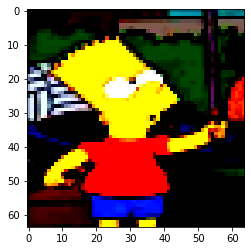

In [139]:
show_example(*dataset[0])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Label:  bart_simpson (0)


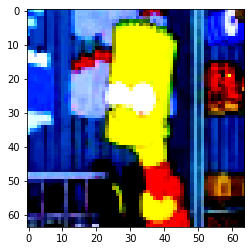

In [140]:
show_example(*dataset[555])

In [ ]:
!pip install jovian --upgrade -q

In [ ]:
import jovian

In [ ]:
jovian.commit(project=project_name)

[jovian] Detected Colab notebook...
[jovian] Uploading colab notebook to Jovian...
[jovian] Capturing environment..
[jovian] Attaching records (metrics, hyperparameters, dataset etc.)
[jovian] Committed successfully! https://jovian.ai/kagsden/final-project


'https://jovian.ai/kagsden/final-project'

#Training and Validation Datasets
While building real world machine learning models, it is quite common to split the dataset into 3 parts:

1. **Training set** - used to train the model i.e. compute the loss and adjust the weights of the model using gradient descent.
2. **Validation set** - used to evaluate the model while training, adjust hyperparameters (learning rate etc.) and pick the best version of the model.
3. **Test set** - used to compare different models, or different types of modeling approaches, and report the final accuracy of the model.

Since there's no predefined validation set, we can set aside a small portion of the training set to be used as the validation set. We'll use the random_split helper method from PyTorch to do this. To ensure that we always create the same validation set, we'll also set a seed for the random number generator.

In [141]:
random_seed = 15
torch.manual_seed(random_seed);

In [142]:
val_size = 600
train_size = len(dataset) - val_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])
len(train_ds), len(val_ds)

(5356, 600)

We can now create data loaders for training and validation, to load the data in batches

In [143]:
batch_size = 64

In [144]:
train_dl = DataLoader(train_ds, batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size*2, num_workers=4, pin_memory=True)

We can look at batches of images from the dataset using the `make_grid` method from `torchvision`. Each time the following code is run, we get a different bach, since the sampler shuffles the indices before creating batches.

In [145]:
from torchvision.utils import make_grid

def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(images, nrow=16).permute(1, 2, 0))
        break

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


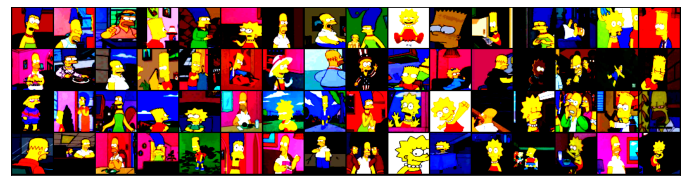

In [146]:
show_batch(train_dl)

In [ ]:
jovian.commit(project=project_name, environment=None)

[jovian] Detected Colab notebook...
[jovian] Uploading colab notebook to Jovian...
[jovian] Attaching records (metrics, hyperparameters, dataset etc.)
[jovian] Committed successfully! https://jovian.ai/kagsden/final-project


'https://jovian.ai/kagsden/final-project'

#Convolutuonal Neural Network
The `Conv2d` layer transforms a 3-channel image to a 16-channel *feature map*, and the `MaxPool2d` layer halves the height and width. The feature map gets smaller as we add more layers, until we are finally left with a small feature map, which can be flattened into a vector. We can then add some fully connected layers at the end to get vector of size 10 for each image.

<img src="https://i.imgur.com/KKtPOKE.png" style="max-width:540px">

Let's define the model by extending an `ImageClassificationBase` class which contains helper methods for training & validation.

In [147]:
class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch 
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss
    
    def validation_step(self, batch):
        images, labels = batch 
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}
        
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}
    
    def epoch_end(self, epoch, result):
        print("Epoch [{}], train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch, result['train_loss'], result['val_loss'], result['val_acc']))
        
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

We'll use nn.Sequential to chain the layers and activations functions into a single network architecture.

In [148]:
class SimpsonsModel(ImageClassificationBase):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 32 x 32 x 32

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 128 x 16 x 16

            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 128 x 8 x 8
            
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 256 x 4 x 4

#             nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
#             nn.ReLU(),
#             nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(2, 2), # output: 256 x 4 x 4

            nn.Flatten(), 
            nn.Linear(256*4*4, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 5))
        
    def forward(self, xb):
        return self.network(xb)

In [149]:
model = SimpsonsModel()
model

SimpsonsModel(
  (network): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (16): ReLU()
    (17): Conv2d(256, 256, kernel_size=(3, 3), stride=(1

Let's verify that the model produces the expected output on a batch of training data. The 5 outputs for each image can be interpreted as probabilities for the 5 target classes (after applying softmax), and the class with the highest probability is chosen as the label predicted by the model for the input image.

In [150]:
for images, labels in train_dl:
    print('images.shape:', images.shape)
    out = model(images)
    print('out.shape:', out.shape)
    print('out[0]:', out[0])
    break

images.shape: torch.Size([64, 3, 64, 64])
out.shape: torch.Size([64, 5])
out[0]: tensor([ 0.0018,  0.0015,  0.0392, -0.0211,  0.0136], grad_fn=<SelectBackward>)


To seamlessly use a GPU, if one is available, we define a couple of helper functions (`get_default_device` & `to_device`) and a helper class `DeviceDataLoader` to move our model & data to the GPU as required.

In [151]:
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')
    
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
        
    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl: 
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

Based on where you're running this notebook, your default device could be a CPU (`torch.device('cpu')`) or a GPU (`torch.device('cuda')`)

In [152]:
device = get_default_device()
device

device(type='cuda')

We can now wrap our training and validation data loaders using `DeviceDataLoader` for automatically transferring batches of data to the GPU (if available), and use `to_device` to move our model to the GPU (if available).

In [153]:
train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
to_device(model, device);

In [ ]:
jovian.commit(project=project_name)

[jovian] Detected Colab notebook...
[jovian] Uploading colab notebook to Jovian...
[jovian] Capturing environment..
[jovian] Attaching records (metrics, hyperparameters, dataset etc.)
[jovian] Committed successfully! https://jovian.ai/kagsden/final-project


'https://jovian.ai/kagsden/final-project'

#Training the model
We'll define two functions: `fit` and `evaluate` to train the model using gradient descent and evaluate its performance on the validation set.

In [154]:
@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        # Training Phase 
        model.train()
        train_losses = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        # Validation phase
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)
    return history

Before we begin training, let's instantiate the model once again and see how it performs on the validation set with the initial set of parameters.

In [155]:
model = to_device(SimpsonsModel(), device)

In [156]:
evaluate(model, val_dl)

{'val_acc': 0.2066761553287506, 'val_loss': 1.613834261894226}

In [110]:
num_epochs = 10
opt_func = torch.optim.Adam
lr = 0.001

In [ ]:
jovian.reset()
jovian.log_hyperparams({
    'num_epochs': num_epochs,
    'opt_func': opt_func.__name__,
    'batch_size': batch_size,
    'lr': lr,
})

[jovian] Hyperparams logged.


In [157]:
history = fit(num_epochs, lr, model, train_dl, val_dl, opt_func)

Epoch [0], train_loss: 1.3169, val_loss: 1.1676, val_acc: 0.4456
Epoch [1], train_loss: 0.9625, val_loss: 0.7766, val_acc: 0.6632
Epoch [2], train_loss: 0.7424, val_loss: 0.6647, val_acc: 0.7084
Epoch [3], train_loss: 0.6583, val_loss: 0.6240, val_acc: 0.7217
Epoch [4], train_loss: 0.5386, val_loss: 0.4630, val_acc: 0.7979
Epoch [5], train_loss: 0.4402, val_loss: 0.3447, val_acc: 0.8580
Epoch [6], train_loss: 0.3053, val_loss: 0.3152, val_acc: 0.8915
Epoch [7], train_loss: 0.2287, val_loss: 0.2868, val_acc: 0.9162
Epoch [8], train_loss: 0.1926, val_loss: 0.2159, val_acc: 0.9186
Epoch [9], train_loss: 0.1811, val_loss: 0.2591, val_acc: 0.9172


In [ ]:
jovian.log_metrics(train_loss=history[-1]['train_loss'], 
                   val_loss=history[-1]['val_loss'], 
                   val_acc=history[-1]['val_acc'])

[jovian] Metrics logged.


We can also plot the valdation set accuracies to study how the model improves over time.

In [158]:
def plot_accuracies(history):
    accuracies = [x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy vs. No. of epochs');

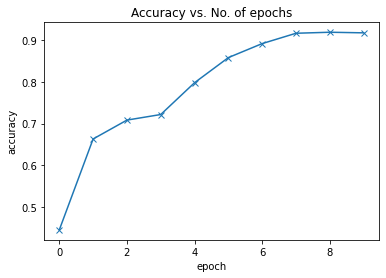

In [159]:
plot_accuracies(history)

In [160]:
def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Loss vs. No. of epochs');

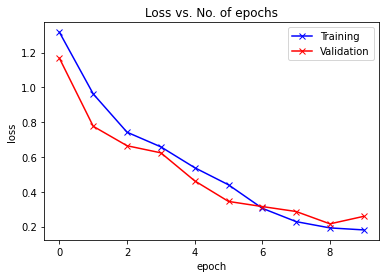

In [161]:
plot_losses(history)

#Testing

In [162]:
 test_dataset = ImageFolder(data_dir+'/test_images', transform= test_tfms)

In [163]:
def predict_image(img, model):
    # Convert to a batch of 1
    xb = to_device(img.unsqueeze(0), device)
    # Get predictions from model
    yb = model(xb)
    # Pick index with highest probability
    _, preds  = torch.max(yb, dim=1)
    # Retrieve the class label
    return dataset.classes[preds[0].item()]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Label: bart_simpson , Predicted: bart_simpson


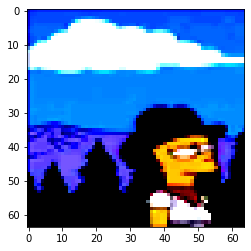

In [164]:
img, label = test_dataset[0]
plt.imshow(img.permute(1, 2, 0))
print('Label:', dataset.classes[label], ', Predicted:', predict_image(img, model))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Label: bart_simpson , Predicted: bart_simpson


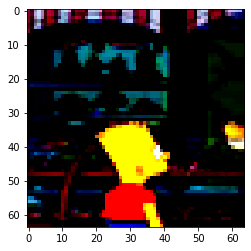

In [165]:
img, label = test_dataset[63]
plt.imshow(img.permute(1, 2, 0))
print('Label:', dataset.classes[label], ', Predicted:', predict_image(img, model))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Label: bart_simpson , Predicted: bart_simpson


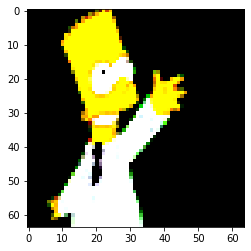

In [166]:
img, label = test_dataset[18]
plt.imshow(img.permute(1, 2, 0))
print('Label:', dataset.classes[label], ', Predicted:', predict_image(img, model))

In [167]:
test_loader = DeviceDataLoader(DataLoader(test_dataset, batch_size*2), device)
result = evaluate(model, test_loader)
result

{'val_acc': 0.762890636920929, 'val_loss': 0.6351535320281982}

In [ ]:
jovian.log_metrics(test_loss=result['val_loss'], test_acc=result['val_acc'])

[jovian] Metrics logged.


Since we've trained our model for a long time and achieved a resonable accuracy, it would be a good idea to save the weights of the model to disk, so that we can reuse the model later and avoid retraining from scratch. Here's how you can save the model.

In [ ]:
torch.save(model.state_dict(), 'simpsons-cnn.pth')

The `.state_dict` method returns an `OrderedDict` containing all the weights and bias matrices mapped to the right attributes of the model. To load the model weights, we can redefine the model with the same structure, and use the `.load_state_dict` method.

In [ ]:
model2 = to_device(SimpsonsModel(), device)

In [ ]:
model2.load_state_dict(torch.load('simpsons-cnn.pth'))

Just as a sanity check, let's verify that this model has the same loss and accuracy on the test set as before.

In [ ]:
evaluate(model2, test_loader)

In [ ]:
jovian.commit(project=project_name)

[jovian] Detected Colab notebook...
[jovian] Uploading colab notebook to Jovian...
[jovian] Capturing environment..
[jovian] Attaching records (metrics, hyperparameters, dataset etc.)
[jovian] Committed successfully! https://jovian.ai/kagsden/final-project


'https://jovian.ai/kagsden/final-project'